Made to inspect models that have been trained.

Reads the most recent training run from results/training

## Libraries

In [2]:
from pathlib import Path
import sys

ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "models").exists():
    ROOT_DIR = ROOT_DIR.parent
sys.path.insert(0, str(ROOT_DIR))

import csv
import matplotlib.pyplot as plt
import torch
import numpy as np
from pathlib import Path
from training.dataset import BRICKDataset
from models.brick import BRICK

## Functions

In [ ]:
# ================================================================================
# FUNCTIONS
# ================================================================================

def list_runs(results_root: Path, subfolder: str = None) -> list:
    """List all runs in results/training or a named subfolder."""
    search_root = results_root / subfolder if subfolder else results_root
    csv_files = sorted(search_root.glob("*/loss_history.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No loss_history.csv found in {search_root}")
    print(f"Available runs in '{subfolder or 'root'}':")
    for i, f in enumerate(csv_files):
        print(f"  [{i+1}] {f.parent.name}")
    return csv_files


def load_csv(csv_path: Path) -> dict:
    """Load loss history CSV into lists."""
    data = {k: [] for k in [
        "epochs",
        "train_total", "val_total",
        "train_recon", "val_recon",
        "train_kl_g0", "val_kl_g0",
        "train_kl_u",  "val_kl_u",
        "train_cls",   "val_cls",
    ]}
    with open(csv_path) as f:
        for row in csv.DictReader(f):
            data["epochs"].append(int(row["epoch"]))
            data["train_total"].append(float(row["train_loss_total"]))
            data["val_total"].append(float(row["val_loss_total"]))
            data["train_recon"].append(float(row["train_loss_recon"]))
            data["val_recon"].append(float(row["val_loss_recon"]))
            data["train_kl_g0"].append(float(row["train_loss_kl_g0"]))
            data["val_kl_g0"].append(float(row["val_loss_kl_g0"]))
            data["train_kl_u"].append(float(row["train_loss_kl_u"]))
            data["val_kl_u"].append(float(row["val_loss_kl_u"]))
            data["train_cls"].append(float(row["train_loss_cls"]))
            data["val_cls"].append(float(row["val_loss_cls"]))
    return data


def load_best_epoch(csv_path: Path) -> int | None:
    """Load the best epoch from the checkpoint in the same directory."""
    checkpoint_path = csv_path.parent / "best_model.pt"
    if checkpoint_path.exists():
        checkpoint = torch.load(checkpoint_path, map_location="cpu")
        best_epoch = checkpoint["epoch"]
        print(f"Best model saved at epoch {best_epoch}")
        return best_epoch
    print("No best_model.pt found.")
    return None


def plot_curves(data: dict, best_epoch: int | None, run_name: str, out_path: Path):
    """Plot all loss curves and save to file."""
    epochs = data["epochs"]

    def plot(ax, title, train, val=None):
        ax.plot(epochs, train, label="train", linewidth=1.5)
        if val is not None:
            ax.plot(epochs, val, label="val", linewidth=1.5, linestyle="--")
        if best_epoch is not None:
            ax.axvline(x=best_epoch, color='red', linestyle=':', linewidth=1.5,
                       label=f"best (ep {best_epoch})")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"BRICK Training Loss Curves\n{run_name}", fontsize=13)

    plot(axes[0, 0], "Total Loss",          data["train_total"],  data["val_total"])
    plot(axes[0, 1], "Reconstruction Loss", data["train_recon"],  data["val_recon"])
    plot(axes[0, 2], "KL g0",               data["train_kl_g0"],  data["val_kl_g0"])
    plot(axes[1, 0], "KL u",                data["train_kl_u"],   data["val_kl_u"])
    plot(axes[1, 1], "Classification Loss", data["train_cls"],    data["val_cls"])
    axes[1, 2].axis("off")

    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved to {out_path}")
    plt.show()


def plot_ablation(results_root: Path, subfolder: str, out_path: Path):
    """Plot all runs in a subfolder overlaid on the same axes."""
    csv_files = list_runs(results_root, subfolder=subfolder)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"BRICK Ablation Comparison\n{subfolder}", fontsize=13)

    def plot(ax, title, key_train, key_val):
        for csv_path in csv_files:
            data = load_csv(csv_path)
            label = csv_path.parent.name
            ax.plot(data["epochs"], data[key_train], label=f"{label} train", linewidth=1.0)
            ax.plot(data["epochs"], data[key_val],   label=f"{label} val",   linewidth=1.0, linestyle="--")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend(fontsize=6)
        ax.grid(alpha=0.3)

    plot(axes[0, 0], "Total Loss",          "train_total",  "val_total")
    plot(axes[0, 1], "Reconstruction Loss", "train_recon",  "val_recon")
    plot(axes[0, 2], "KL g0",               "train_kl_g0",  "val_kl_g0")
    plot(axes[1, 0], "KL u",                "train_kl_u",   "val_kl_u")
    plot(axes[1, 1], "Classification Loss", "train_cls",    "val_cls")
    axes[1, 2].axis("off")

    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved to {out_path}")
    plt.show()

## PLOT

Available runs in 'root':
  [1] train_20260618_143928
  [2] train_20260618_144852
  [3] train_20260619_125015
  [4] train_20260619_134312
  [5] train_20260619_150129
  [6] train_20260622_094554
  [7] train_20260622_140945
  [8] train_20260622_144244
  [9] train_20260622_145154
  [10] train_20260622_160853
  [11] train_20260622_161907
  [12] train_20260623_092253
  [13] train_20260623_093759
  [14] train_20260623_094912
  [15] train_20260623_095954
  [16] train_20260623_101131
  [17] train_20260623_102656
  [18] train_20260623_104108
  [19] train_20260623_104941
  [20] train_20260623_114247
  [21] train_20260623_131014
  [22] train_20260623_132944
  [23] train_20260623_134241
  [24] train_20260623_134655
  [25] train_20260623_135251
  [26] train_20260623_141354
  [27] train_20260623_142622
  [28] train_20260623_154554
  [29] train_20260623_155811
  [30] train_20260623_160725
  [31] train_20260623_161803
  [32] train_20260623_162620
  [33] train_20260624_150557
  [34] train_20260625_0918

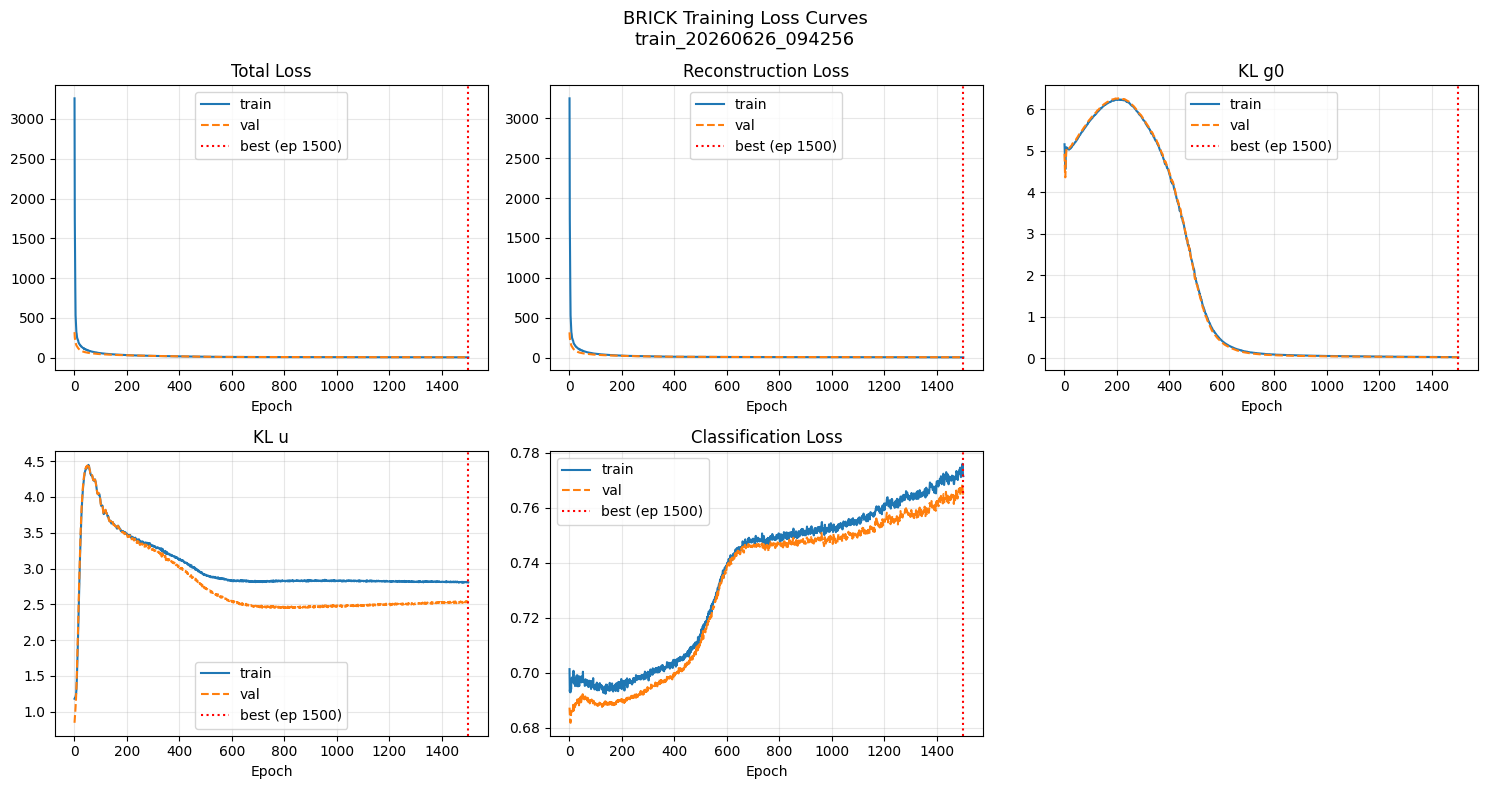

In [7]:
TRAIN_NUMBER = 40  # <-- change this
SUBFOLDER = None  # e.g. "sweep_1", "ablation_BETA=0", or None for root

results_root = ROOT_DIR / "results" / "training"

csv_files  = list_runs(results_root, subfolder=SUBFOLDER)
csv_path   = csv_files[TRAIN_NUMBER - 1]
print(f"\nPlotting: {csv_path.parent.name}")

data       = load_csv(csv_path)
best_epoch = load_best_epoch(csv_path)
out_path   = ROOT_DIR / "results" / "figures" / f"training_curves_{csv_path.parent.name}.png"

plot_curves(data, best_epoch, csv_path.parent.name, out_path)

Available runs in 'ablation_BETA=0':
  [1] ablation_full
  [2] ablation_no_control
  [3] ablation_no_control_no_ic
  [4] ablation_no_ic

Plotting: ablation_full
Best model saved at epoch 1399
Saved to c:\Users\USER\Documents\GitHub\LIFUS-BRICK\results\figures\training_curves_ablation_full.png


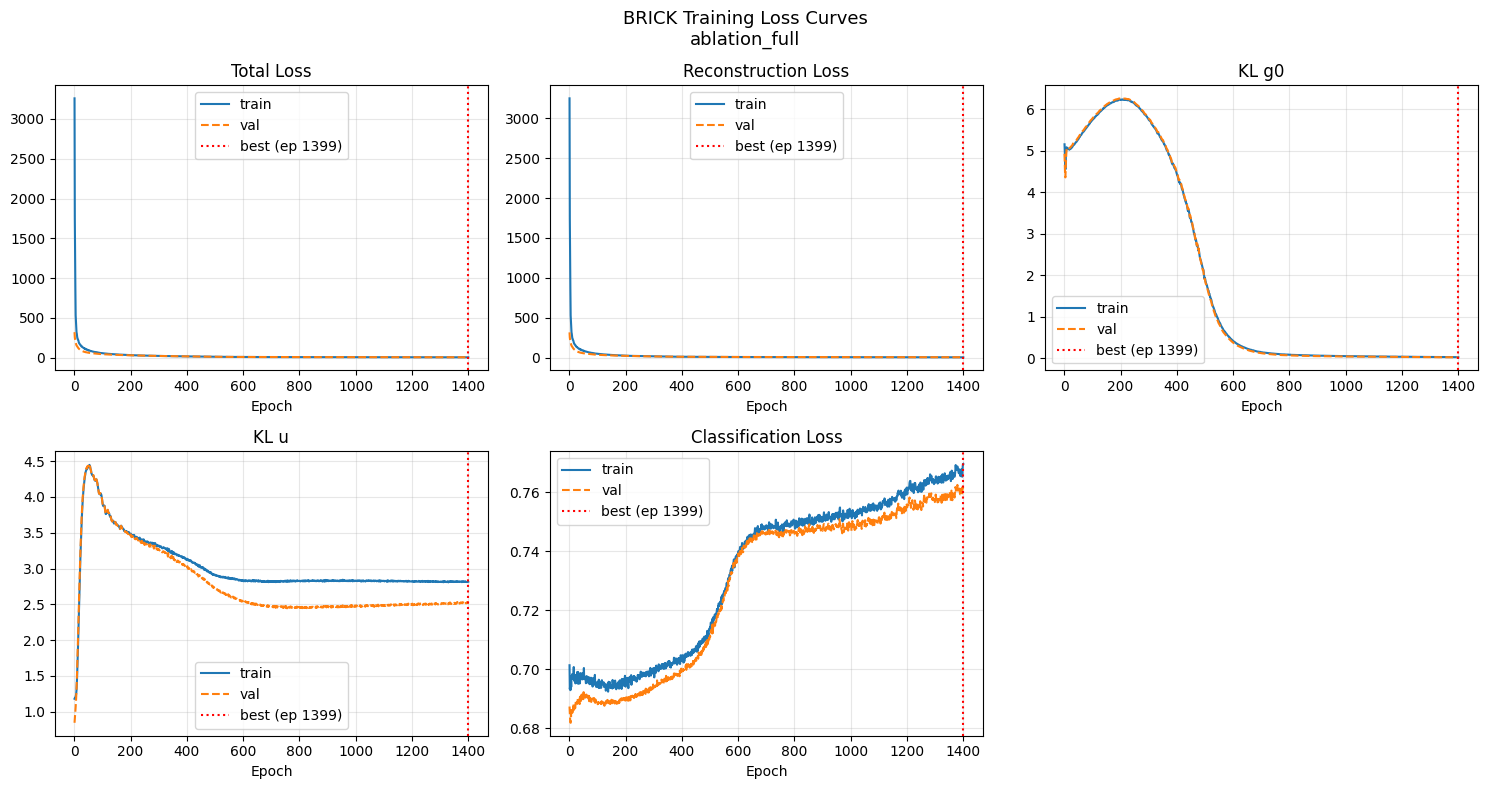

In [10]:
TRAIN_NUMBER = 1  # <-- change this
SUBFOLDER = "ablation_BETA=0"  # e.g. "sweep_1", "ablation_BETA=0", or None for root

results_root = ROOT_DIR / "results" / "training"

csv_files  = list_runs(results_root, subfolder=SUBFOLDER)
csv_path   = csv_files[TRAIN_NUMBER - 1]
print(f"\nPlotting: {csv_path.parent.name}")

data       = load_csv(csv_path)
best_epoch = load_best_epoch(csv_path)
out_path   = ROOT_DIR / "results" / "figures" / f"training_curves_{csv_path.parent.name}.png"

plot_curves(data, best_epoch, csv_path.parent.name, out_path)

### Test Load Model

In [ ]:
import torch
from models.brick import BRICK

checkpoint = torch.load("results/training/your_run_name/best_model.pt")

model = BRICK(
    use_control=checkpoint["use_control"],
    use_ic=checkpoint["use_ic"],
    h=checkpoint["h"],
    m=checkpoint["m"],
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

### Test for VAE posterior collapse vs code bug (grdients not flowing properly)

In [7]:
import torch
from training.dataset import BRICKDataset
from models.brick import BRICK
from pathlib import Path

ds = BRICKDataset(Path("data/preprocessed_data"))

checkpoint = torch.load("results/training/train_20260619_134312/best_model.pt", map_location="cpu")
model = BRICK(use_control=True, use_ic=True, h=2, nhead=2)
model.load_state_dict(checkpoint["model_state_dict"])
model.train()

x     = ds[0]["x"]
label = ds[0]["lifus_condition"]
out   = model(x, label)
out["losses"]["loss_total"].backward()

print("Encoder gradients:")
for name, param in model.encoder.named_parameters():
    if param.grad is not None:
        print(f"  {name}: grad_norm={param.grad.norm().item():.6f}")
    else:
        print(f"  {name}: NO GRADIENT")

Encoder gradients:
  row_mlp.0.weight: grad_norm=0.000000
  row_mlp.0.bias: grad_norm=0.000000
  row_mlp.2.weight: grad_norm=0.000000
  row_mlp.2.bias: grad_norm=0.000000
  mu_head.layers.0.self_attn.in_proj_weight: grad_norm=0.000000
  mu_head.layers.0.self_attn.in_proj_bias: grad_norm=0.000000
  mu_head.layers.0.self_attn.out_proj.weight: grad_norm=0.000000
  mu_head.layers.0.self_attn.out_proj.bias: grad_norm=0.000000
  mu_head.layers.0.linear1.weight: grad_norm=0.000000
  mu_head.layers.0.linear1.bias: grad_norm=0.000000
  mu_head.layers.0.linear2.weight: grad_norm=0.000000
  mu_head.layers.0.linear2.bias: grad_norm=0.000000
  mu_head.layers.0.norm1.weight: grad_norm=0.000000
  mu_head.layers.0.norm1.bias: grad_norm=0.000000
  mu_head.layers.0.norm2.weight: grad_norm=0.000083
  mu_head.layers.0.norm2.bias: grad_norm=0.000083
  mu_head.layers.1.self_attn.in_proj_weight: grad_norm=0.000056
  mu_head.layers.1.self_attn.in_proj_bias: grad_norm=0.000040
  mu_head.layers.1.self_attn.out_

This is vanishing gradients in the early layers — a secondary issue on top of posterior collapse. The first row_mlp and first transformer layer are essentially not learning because gradients diminish as they backpropagate through the network.
This is expected behavior for a collapsed VAE — when mu≈0 and sigma≈1 (prior), the KL gradient is near zero, so very little signal flows back through the encoder. It's a consequence of collapse, not an independent bug.
Conclusion: No code bug. The collapse is genuine VAE behavior caused by the loss landscape. KL annealing is the right fix — it forces reconstruction gradients to flow through the encoder before KL pressure can cause collapse, which would give the early layers a chance to learn.